In [67]:
import pandas as pd

df =pd.read_parquet("data.parquet")

## Conversion des types

In [68]:
# domaine_etude => qualitative nominale
# get_dummies drop automatiquement ["domaine_etude"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["domaine_etude"], drop_first=True)

In [69]:
# statut_marital => qualitative nominale
# get_dummies drop automatiquement ["statut_marital"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["statut_marital"], drop_first=True)


In [70]:
# departement => qualitative nominale
# get_dummies drop automatiquement ["departement"]
# drop_first = Supprime la 1er catégorie (Commercial) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["departement"], drop_first=True)


In [71]:
# poste => qualitative nominale
# get_dummies drop automatiquement ["poste"]
# drop_first = Supprime la 1er catégorie (Assistant) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["poste"], drop_first=True)

In [72]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,bool
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,niveau_education,int64
5,frequence_deplacement,int64
6,annees_depuis_la_derniere_promotion,int64
7,annes_sous_responsable_actuel,int64
8,age,int64
9,revenu_mensuel,int64


# corrélation de Pearson

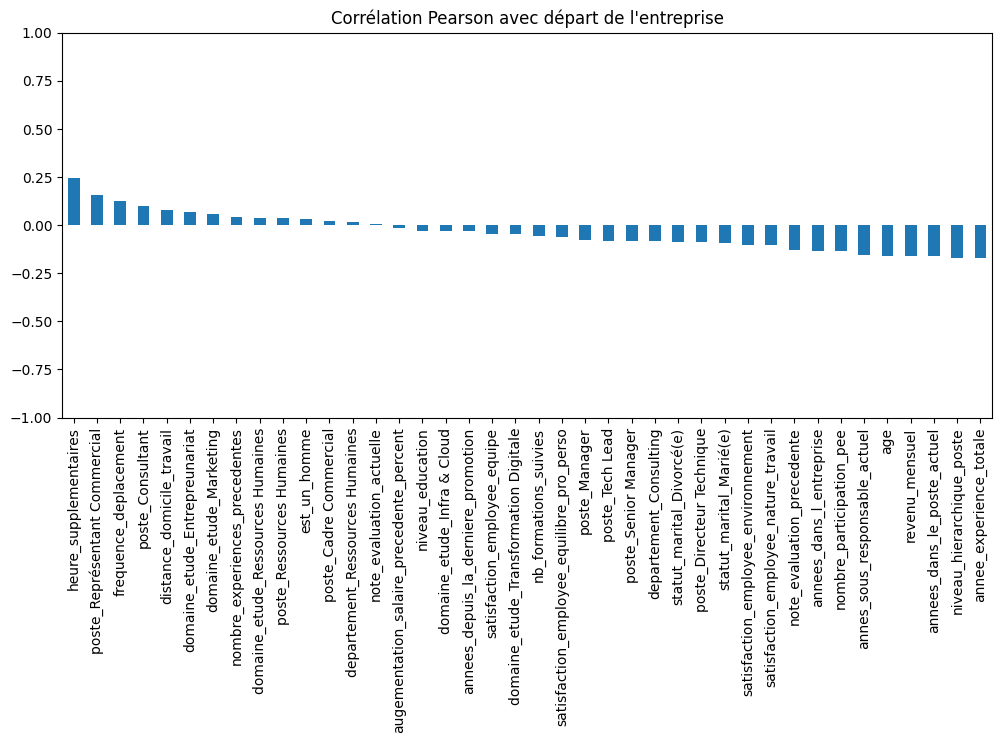

In [73]:
import matplotlib.pyplot as plt

df["a_quitte_l_entreprise"] = df["a_quitte_l_entreprise"].astype(int)

target_corr = df.corr(numeric_only=True)["a_quitte_l_entreprise"].sort_values(ascending=False)

target_corr.drop("a_quitte_l_entreprise").plot(kind="bar", figsize=(12,5))
plt.title("Corrélation Pearson avec départ de l'entreprise")
plt.ylim(-1, 1)
plt.show()

# séparation train/test

In [74]:
def separation_train_test():
    global X, y, X_train, X_test, y_train, y_test

    X = df.drop(columns=['a_quitte_l_entreprise'])
    y = df['a_quitte_l_entreprise']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    print(f"Taille du jeu d'entraînement : {X_train.shape[0]} lignes")
    print(f"Taille du jeu de test : {X_test.shape[0]} lignes")


# choix de l’algorithme (régression, classification, clustering…)

Ici on cherche à prédire le départ ou non d'un salarié, il s'agit d'une classification binaire.

Nous allons tester les modèles suivants en parallèle

* Régression logistique (LogisticRegression)
* Arbres de décision (DecisionTreeClassifier)
* Forêts aléatoires (RandomForestClassifier)
* Gradient Boosting (XGBoost **, LightGBM, CatBoost, GradientBoostingClassifier)

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier

def entrainement_model(model_name: str, params, pred_test = True):

    # choix de l’algorithme (régression, classification, clustering…)
    global X_train, X_test, y_train, y_test, threshold


    if model_name == "LogisticRegression":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(**params))
        ])
    elif model_name == "RandomForestClassifier":
        model = RandomForestClassifier(**params)
    elif model_name == "DecisionTreeClassifier":
        model = DecisionTreeClassifier(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(**params)
    elif model_name == "DummyClassifier":
        model = DummyClassifier(**params)
    else:
        raise ValueError(f"Modèle {model_name} non supporté")

    # Entraînement
    model.fit(X_train, y_train)

    if pred_test == True:

        # Prédictions
        y_pred = model.predict(X_test)
        
        # obtient la probabilité d’appartenance à chaque classe des prédictions (pour mesurer les scores et ajuster les prédictions)
        y_proba = model.predict_proba(X_test)[:, 1]

        # ajuste les prédictions en fonction du seuil de probabilité
        y_pred = (y_proba >= threshold)

        # évaluation des performances (accuracy, RMSE, F1, etc.)
        return {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "r2": r2_score(y_test, y_pred),
            "auc" : roc_auc_score(y_test, y_proba),
            "y_proba" : y_proba,
            "y_pred" : y_pred,
            "X" : X_test,
            "y" : y_test,
            "clf" : model
        }

    # Prédictions
    y_pred_train = model.predict(X_train)
    
    # obtient la probabilité d’appartenance à chaque classe des prédictions (pour mesurer les scores et ajuster les prédictions)
    y_proba_train = model.predict_proba(X_train)[:, 1]

    # ajuste les prédictions en fonction du seuil de probabilité
    y_pred_train = (y_proba_train >= threshold)

    # évaluation des performances (accuracy, RMSE, F1, etc.)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_train, y_pred_train),
        "precision": precision_score(y_train, y_pred_train),
        "recall": recall_score(y_train, y_pred_train),
        "f1": f1_score(y_train, y_pred_train),
        "r2": r2_score(y_train, y_pred_train),
        "auc" : roc_auc_score(y_train, y_proba_train),
        "y_proba" : y_proba_train,
        "y_pred" : y_pred_train,
        "X" : X_train,
        "y" : y_train,
        "clf" : model
    }


# Résultat

In [76]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def print_results(*args) -> None:
    print("R²")
    print("   1.0   = (bon modèle)           prédictions exactes ")
    print("   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple ")
    print("   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne ")

    print()

    print("precision / recall")
    print("   Precision = fiabilité des alertes")
    print("               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)")
    print("   Recall    = capacité à détecter les vrais cas")
    print("               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués")
    print("   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)")
    print("   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs")

    print()

    print("AUC")
    print("   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.")

    for results_list in args:
        results = pd.DataFrame(results_list)
        display(results)

    
def display_results(*args) -> None:
    for results_list in args:
        i = 0
        fig, axes = plt.subplots(3, len(results_list), figsize=(15, 10))

        for results in results_list:
            ax = axes[0,i]
            sns.histplot(
                results["y_proba"],
                ax=axes[0,i])
            
            ConfusionMatrixDisplay.from_predictions(
                results["y"],
                results["y_pred"],
                ax=axes[1,i]
            )

            from sklearn.metrics import roc_curve
            fpr, tpr, thresholds = roc_curve(results["y"], results["clf"].predict_proba(results["X"])[:,1])
            plt.axes(axes[2,i])
            plt.plot(fpr, tpr)
            plt.grid()
            plt.title("ROC curve")
            
            ax.set_title(results["model"])
            i = i+1

        plt.tight_layout()
        plt.show()


# entraînement du modèle

In [77]:
pass_list = []

# séparation train/test

separation_train_test()

# Par défaut nous partons sur le seuil d'ajustement des classes par défaut: 0.5
threshold = 0.5

#
# paramètres de chaque modèle
#

# un modèle linéaire
LogisticRegressionParams = {
    
}

# un modèle dummy
DummyClassifierParams = {
    "strategy":"stratified"
}

# un modèle non-linéaire
XGBoostParams = {
    "n_estimators": 200,
    "max_depth": 4,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "logloss"
}

#
# autres paramètres de modèles (pour test)
#

RandomForestClassifierParams = {
    "n_estimators": 200,
    "random_state": 42
}

DecisionTreeClassifierParams = {
    "max_depth": 4,
    "random_state": 42
}


Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


In [78]:
# entrainement de base avec tous les paramètres

results_list = []
results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams))
results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
results_list.append(entrainement_model("XGBoost", XGBoostParams))
pass_list.append(results_list)

In [79]:
train_results_list = []
train_results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams, False))
train_results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams, False))
train_results_list.append(entrainement_model("XGBoost", XGBoostParams, False))

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred,X,y,clf
0,DummyClassifier,0.765306,0.142857,0.153846,0.148148,-1.039819,0.506335,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, True, Fals...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,DummyClassifier(strategy='stratified')
1,LogisticRegression,0.880952,0.576923,0.384615,0.461538,-0.034691,0.790950,"[0.05856341385660687, 0.002527058959137481, 0....","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,"(StandardScaler(), LogisticRegression())"
2,XGBoost,0.874150,0.538462,0.358974,0.430769,-0.093816,0.799296,"[0.028785374, 0.016901327, 0.3239123, 0.014594...","[False, False, False, False, False, True, Fals...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,"XGBClassifier(base_score=None, booster=None, c..."


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred,X,y,clf
0,DummyClassifier,0.712585,0.146465,0.146465,0.146465,-1.052674,0.486832,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, ...","[False, False, False, False, False, True, Fals...",nombre_participation_pee nb_formations_...,1097 0 727 0 254 0 1175 0 1341 ...,DummyClassifier(strategy='stratified')
1,LogisticRegression,0.887755,0.761905,0.484848,0.592593,0.198364,0.882460,"[0.3464314329445514, 0.03622754576247082, 0.01...","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1097 0 727 0 254 0 1175 0 1341 ...,"(StandardScaler(), LogisticRegression())"
2,XGBoost,0.994898,1.000000,0.969697,0.984615,0.963562,0.999974,"[0.1252557, 0.070943005, 0.0020979424, 0.02955...","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1097 0 727 0 254 0 1175 0 1341 ...,"XGBClassifier(base_score=None, booster=None, c..."


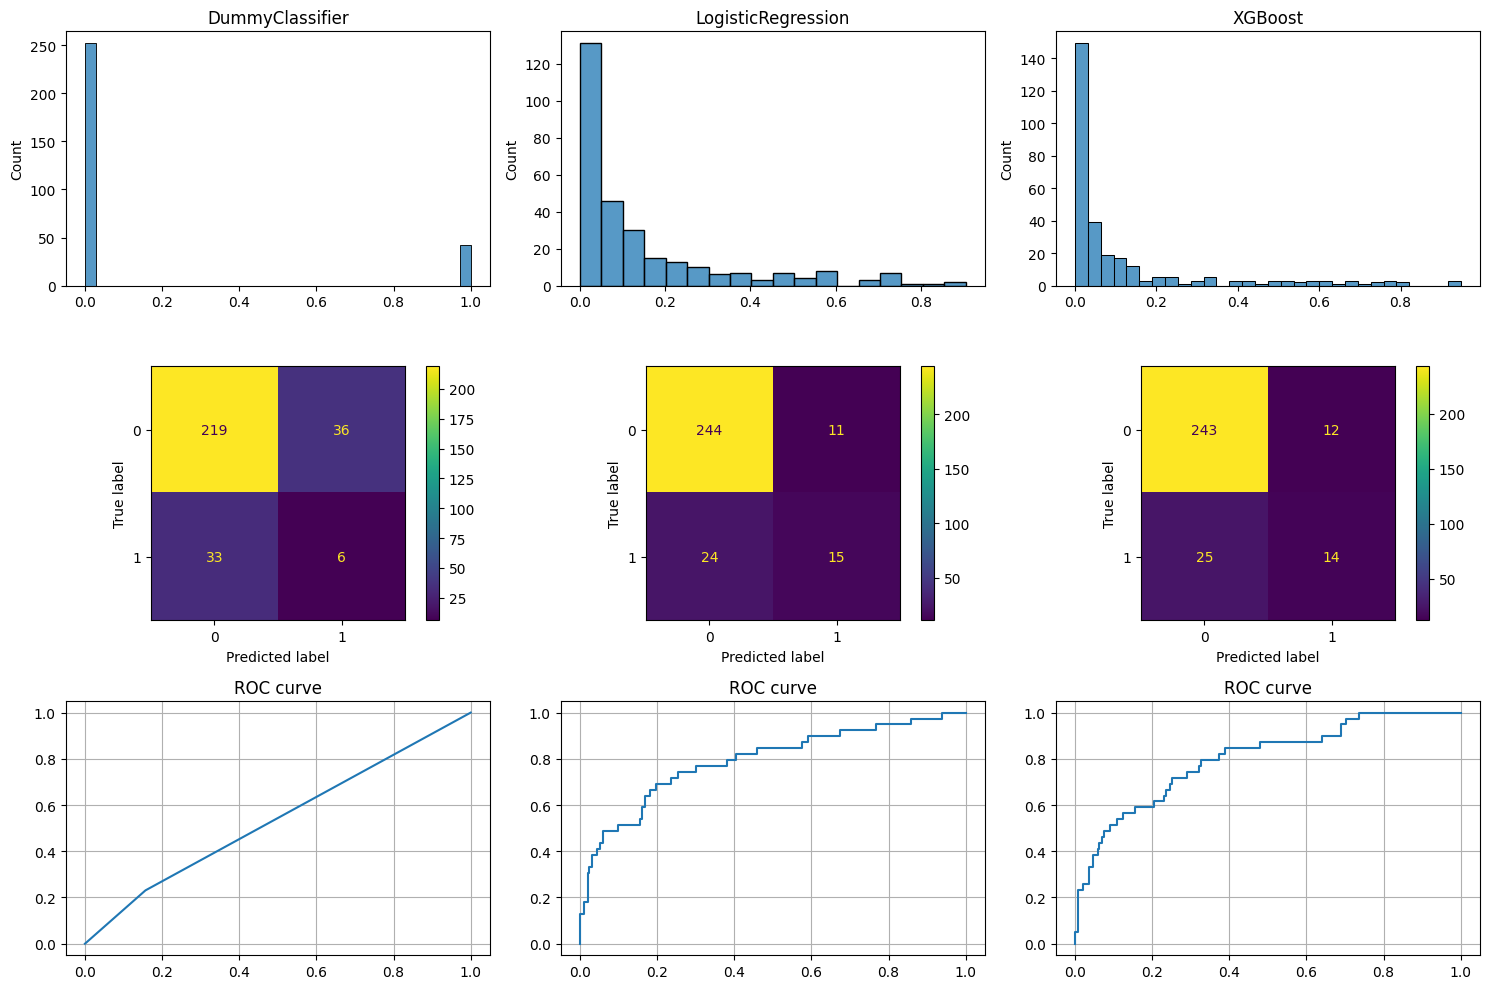

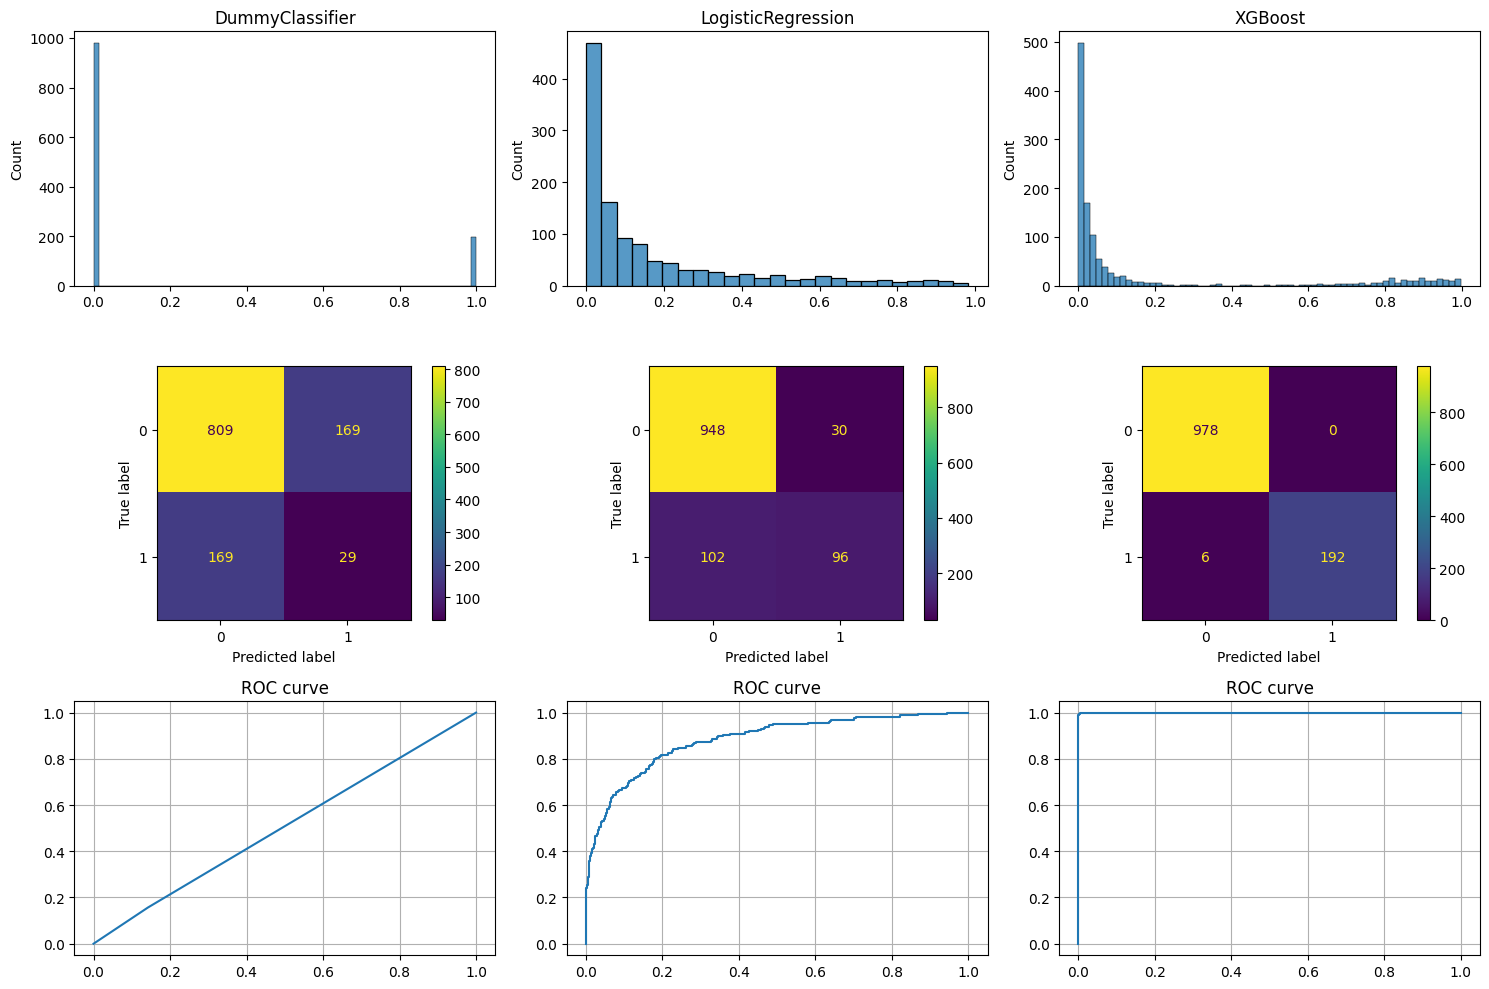

In [80]:
print_results(results_list, train_results_list)
display_results(results_list, train_results_list)

In [81]:
# on essaie de supprimer la feature "niveau_hierarchique_poste" (fortement corrélé à "revenu_mensuel")

df.drop(columns=["niveau_hierarchique_poste"], inplace=True)

separation_train_test()

results_list = []
results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams))
results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
results_list.append(entrainement_model("XGBoost", XGBoostParams))
pass_list.append(results_list)

Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


In [82]:
train_results_list = []
train_results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams, False))
train_results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams, False))
train_results_list.append(entrainement_model("XGBoost", XGBoostParams, False))

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred,X,y,clf
0,DummyClassifier,0.717687,0.092593,0.128205,0.107527,-1.453695,0.468024,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, True, Fals...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,DummyClassifier(strategy='stratified')
1,LogisticRegression,0.884354,0.592593,0.410256,0.484848,-0.005128,0.791151,"[0.05718505214507036, 0.00255999765960861, 0.3...","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,"(StandardScaler(), LogisticRegression())"
2,XGBoost,0.880952,0.590909,0.333333,0.426230,-0.034691,0.785219,"[0.02034307, 0.0141866375, 0.19582923, 0.02361...","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,"XGBClassifier(base_score=None, booster=None, c..."


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred,X,y,clf
0,DummyClassifier,0.718537,0.140541,0.131313,0.135770,-1.010163,0.484368,"[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[True, True, False, False, False, False, False...",nombre_participation_pee nb_formations_...,1097 0 727 0 254 0 1175 0 1341 ...,DummyClassifier(strategy='stratified')
1,LogisticRegression,0.886054,0.753968,0.479798,0.586420,0.186218,0.882522,"[0.3467051661313502, 0.037175919090040095, 0.0...","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1097 0 727 0 254 0 1175 0 1341 ...,"(StandardScaler(), LogisticRegression())"
2,XGBoost,0.995748,1.000000,0.974747,0.987212,0.969635,0.999964,"[0.08926819, 0.061738454, 0.0031753292, 0.0170...","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1097 0 727 0 254 0 1175 0 1341 ...,"XGBClassifier(base_score=None, booster=None, c..."


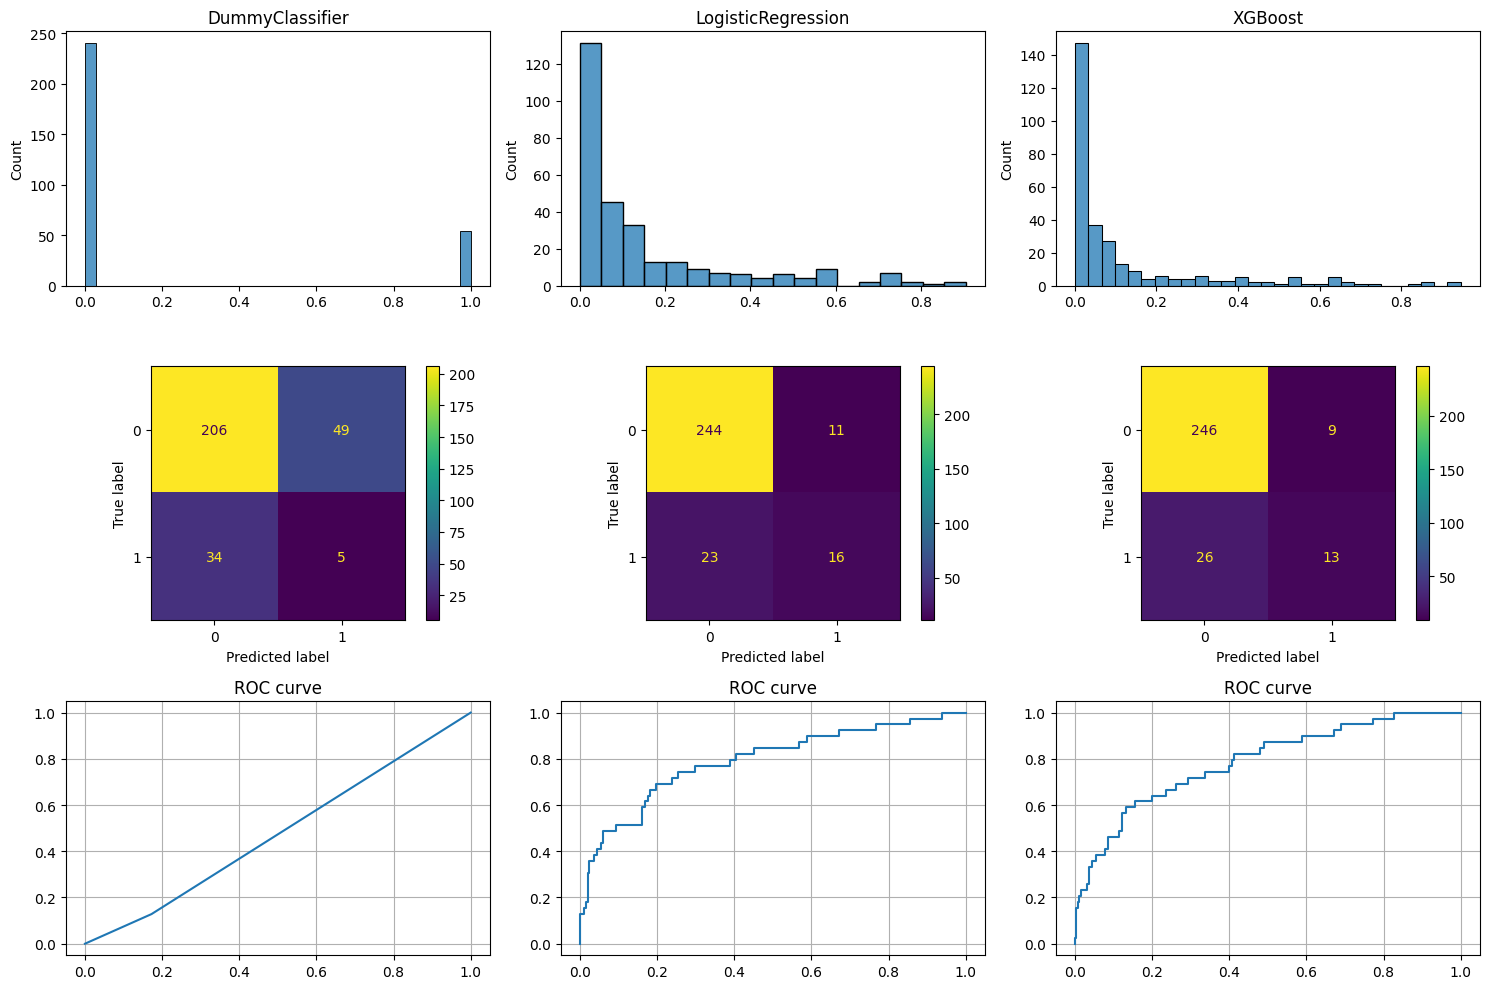

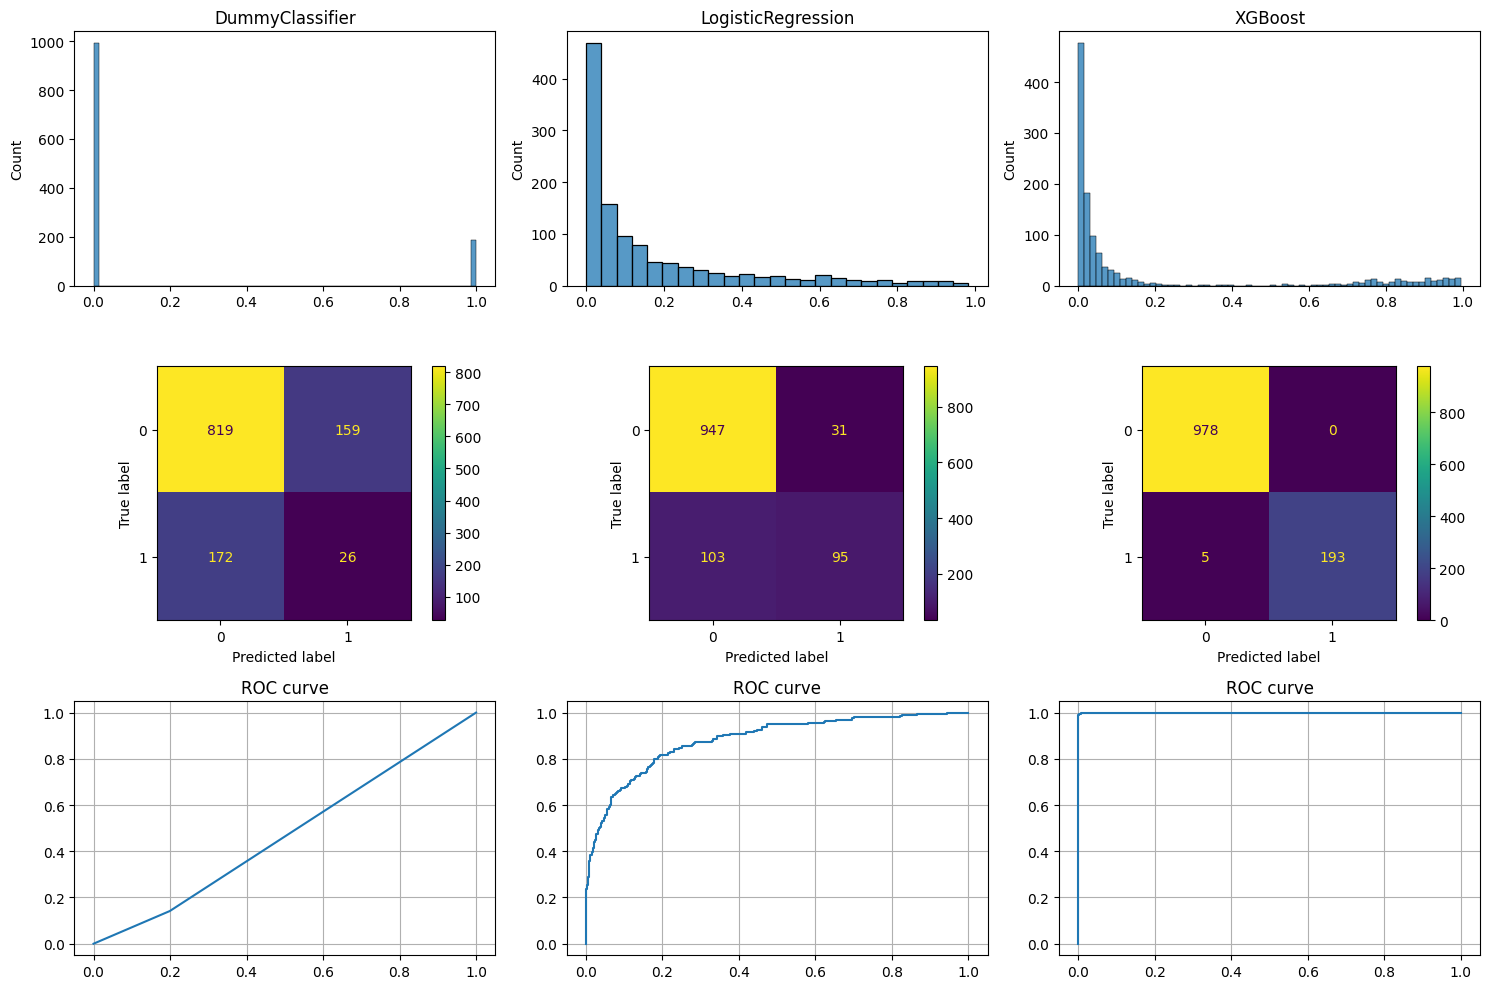

In [83]:
print_results(results_list, train_results_list)
display_results(results_list, train_results_list)

# Overfit

* Le modèle XGBoost présente un fort Sur-apprentissage sur le jeu d'entrainement F1-score 0.98 / 0.42
* Le modèle LogisticRegression est moins affecté par le Sur-apprentissage 0.48 / 0.58
* Les modèles restent meilleur que le dummy de référence


Remédiations:
* Vérifier la qualité du découpage entraînement / test => contrôler les doublons d’ID ou les chevauchements de groupes entre train et test ou split par groupe plutôt qu’un split aléatoire
* Vérifier la présence de fuite de données dans les variables explicatives => revue des features et de leur mode de calcul est souvent nécessaire, en particulier pour les agrégations
* Une complexité excessive du modèle par rapport à la quantité de données => la régularisation, la réduction de profondeur, le subsampling des lignes et des colonnes permettent de forcer une généralisation plus robuste

# Vérifie la répartition des données train/test

In [84]:
df["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
0    0.838776
1    0.161224
Name: proportion, dtype: float64

In [85]:
y_train.value_counts(normalize=True)

a_quitte_l_entreprise
0    0.831633
1    0.168367
Name: proportion, dtype: float64

In [86]:
y_test.value_counts(normalize=True)

a_quitte_l_entreprise
0    0.867347
1    0.132653
Name: proportion, dtype: float64

La répartition true / false est plutot bien répartie

# amélioration du modèle

In [87]:
RandomForestClassifierParams["class_weight"] = "balanced"
XGBoostParams["scale_pos_weight"] = 986 / 190

results_list = []
results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams))
results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
results_list.append(entrainement_model("XGBoost", XGBoostParams))
pass_list.append(results_list)

In [88]:
train_results_list = []
train_results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams, False))
train_results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams, False))
train_results_list.append(entrainement_model("XGBoost", XGBoostParams, False))

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred,X,y,clf
0,DummyClassifier,0.724490,0.150000,0.230769,0.181818,-1.394570,0.515385,"[0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, ...","[False, False, False, True, False, True, False...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,DummyClassifier(strategy='stratified')
1,LogisticRegression,0.884354,0.592593,0.410256,0.484848,-0.005128,0.791151,"[0.05718505214507036, 0.00255999765960861, 0.3...","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,"(StandardScaler(), LogisticRegression())"
2,XGBoost,0.877551,0.538462,0.538462,0.538462,-0.064253,0.795274,"[0.11183757, 0.02277506, 0.5167675, 0.03024532...","[False, False, True, False, False, True, False...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,"XGBClassifier(base_score=None, booster=None, c..."


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred,X,y,clf
0,DummyClassifier,0.713435,0.143590,0.141414,0.142494,-1.046601,0.485329,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, True, False, False, Fals...",nombre_participation_pee nb_formations_...,1097 0 727 0 254 0 1175 0 1341 ...,DummyClassifier(strategy='stratified')
1,LogisticRegression,0.886054,0.753968,0.479798,0.586420,0.186218,0.882522,"[0.3467051661313502, 0.037175919090040095, 0.0...","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1097 0 727 0 254 0 1175 0 1341 ...,"(StandardScaler(), LogisticRegression())"
2,XGBoost,0.994048,0.965854,1.000000,0.982630,0.957489,1.000000,"[0.129222, 0.09770905, 0.014387135, 0.04926621...","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1097 0 727 0 254 0 1175 0 1341 ...,"XGBClassifier(base_score=None, booster=None, c..."


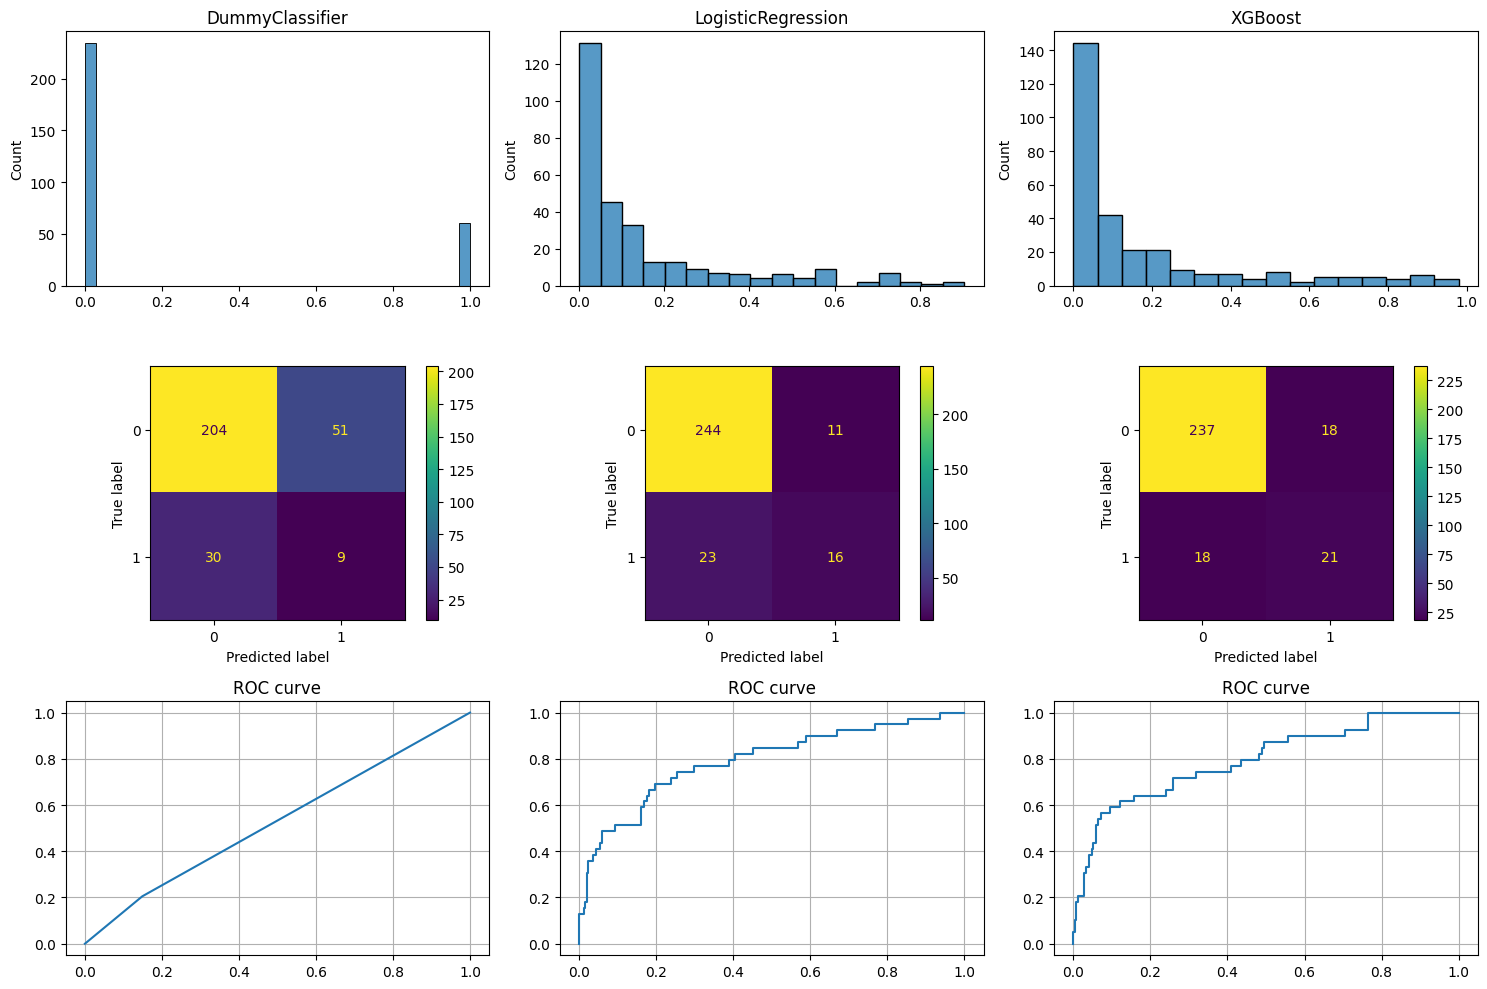

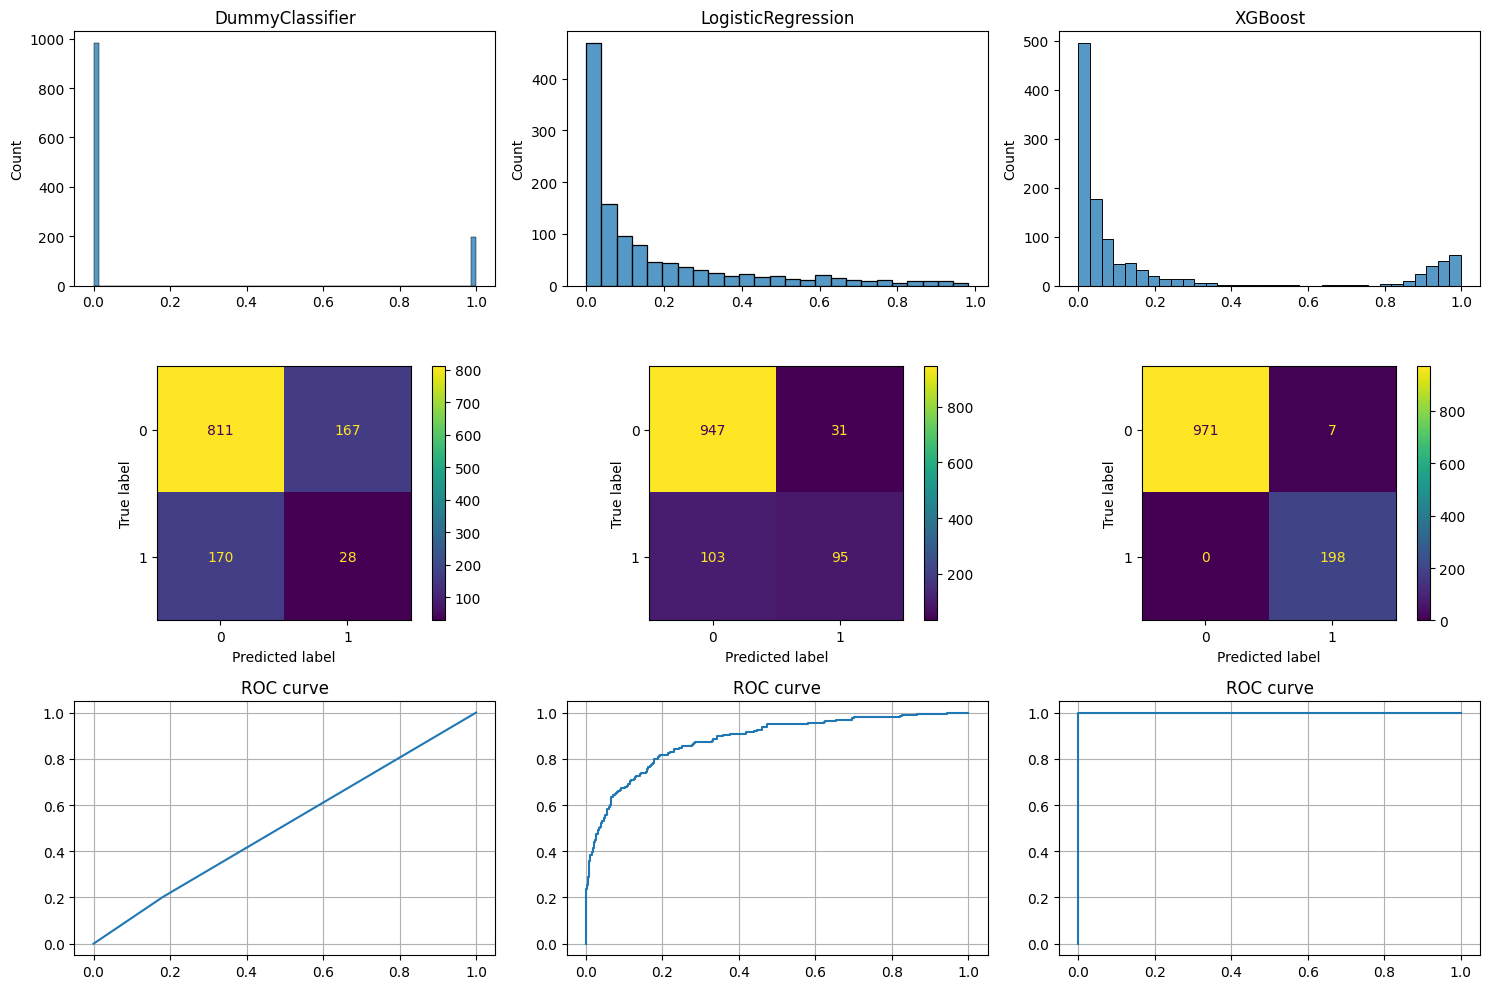

In [89]:
print_results(results_list, train_results_list)
display_results(results_list, train_results_list)

In [90]:
df["pression_travail"] = df["heure_supplementaires"] * df["frequence_deplacement"]

df["insatisfaction_globale"] = (
    df["satisfaction_employee_nature_travail"] +
    df["satisfaction_employee_equipe"] +
    df["satisfaction_employee_equilibre_pro_perso"]
)

df.drop(columns=["satisfaction_employee_nature_travail"], inplace=True)
df.drop(columns=["satisfaction_employee_equipe"], inplace=True)
df.drop(columns=["satisfaction_employee_equilibre_pro_perso"], inplace=True)
df.drop(columns=["heure_supplementaires"], inplace=True)
df.drop(columns=["frequence_deplacement"], inplace=True)

# séparation train/test
separation_train_test()

results_list = []
results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams))
results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
results_list.append(entrainement_model("XGBoost", XGBoostParams))
pass_list.append(results_list)

Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


In [91]:
train_results_list = []
train_results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams, False))
train_results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams, False))
train_results_list.append(entrainement_model("XGBoost", XGBoostParams, False))

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred,X,y,clf
0,DummyClassifier,0.772109,0.181818,0.205128,0.192771,-0.980694,0.531976,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, True, False, False, Fals...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,DummyClassifier(strategy='stratified')
1,LogisticRegression,0.877551,0.560000,0.358974,0.437500,-0.064253,0.775163,"[0.04998012406583956, 0.003395113087282791, 0....","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,"(StandardScaler(), LogisticRegression())"
2,XGBoost,0.823129,0.341463,0.358974,0.350000,-0.537255,0.778984,"[0.056196146, 0.008982177, 0.5300816, 0.011295...","[False, False, True, False, False, True, False...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,"XGBClassifier(base_score=None, booster=None, c..."


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred,X,y,clf
0,DummyClassifier,0.703231,0.131707,0.136364,0.133995,-1.119477,0.477180,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, False, False, False, False, False, Fals...",nombre_participation_pee nb_formations_...,1097 0 727 0 254 0 1175 0 1341 ...,DummyClassifier(strategy='stratified')
1,LogisticRegression,0.876701,0.722689,0.434343,0.542587,0.119415,0.874579,"[0.36225319386596977, 0.1050449171671756, 0.02...","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1097 0 727 0 254 0 1175 0 1341 ...,"(StandardScaler(), LogisticRegression())"
2,XGBoost,0.994898,0.970588,1.000000,0.985075,0.963562,1.000000,"[0.2598917, 0.21183299, 0.008120779, 0.1371205...","[False, False, False, False, False, False, Fal...",nombre_participation_pee nb_formations_...,1097 0 727 0 254 0 1175 0 1341 ...,"XGBClassifier(base_score=None, booster=None, c..."


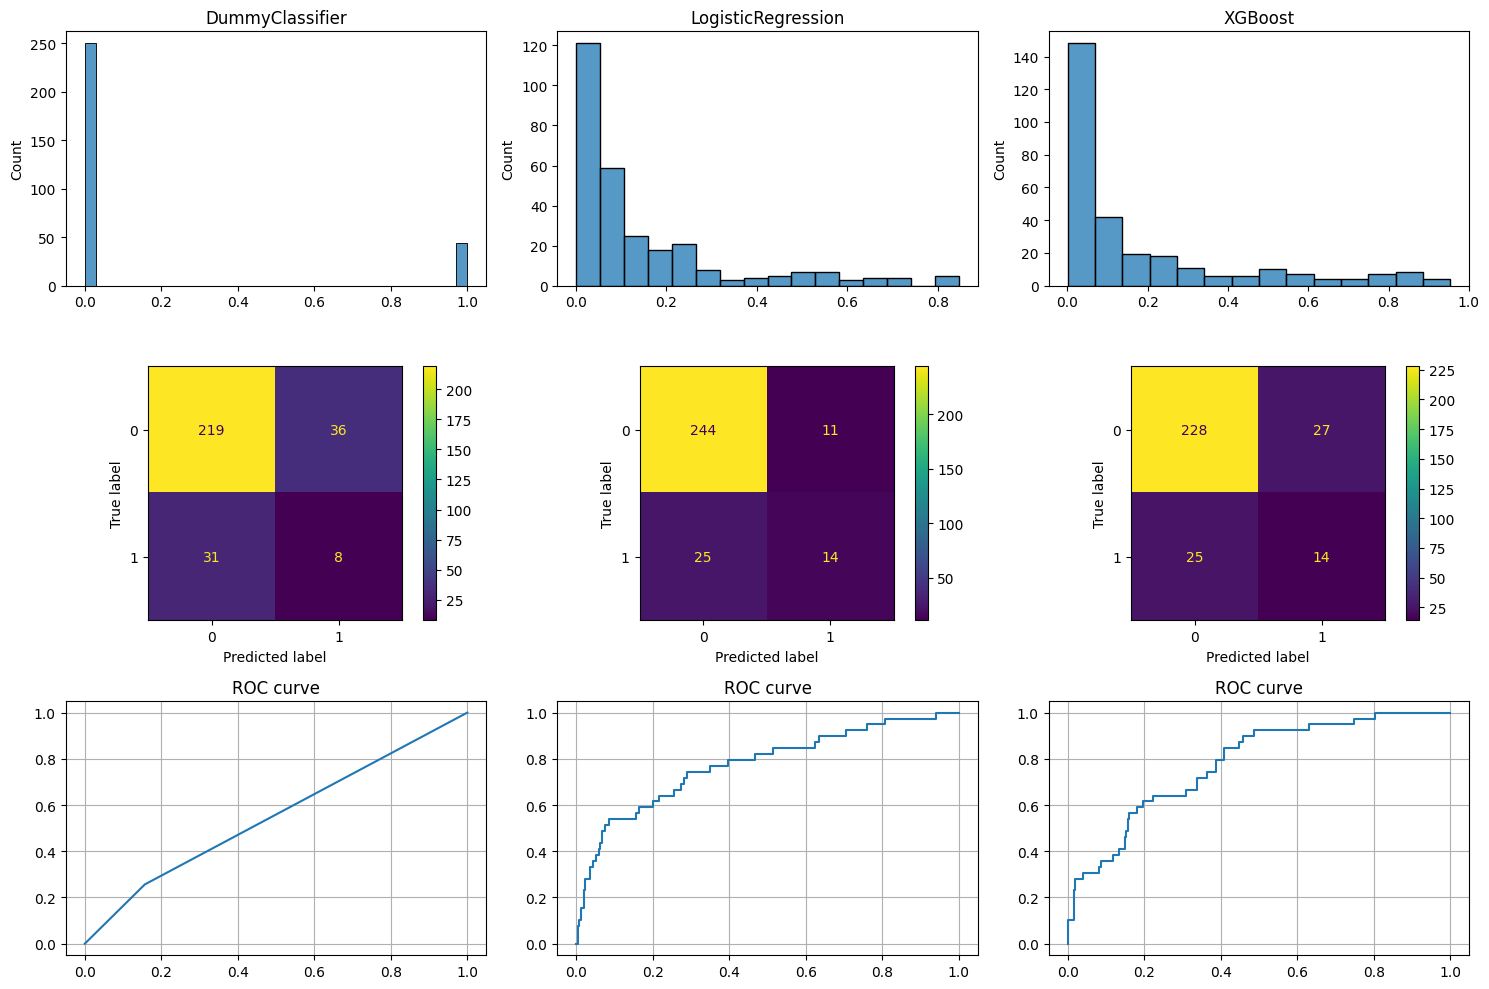

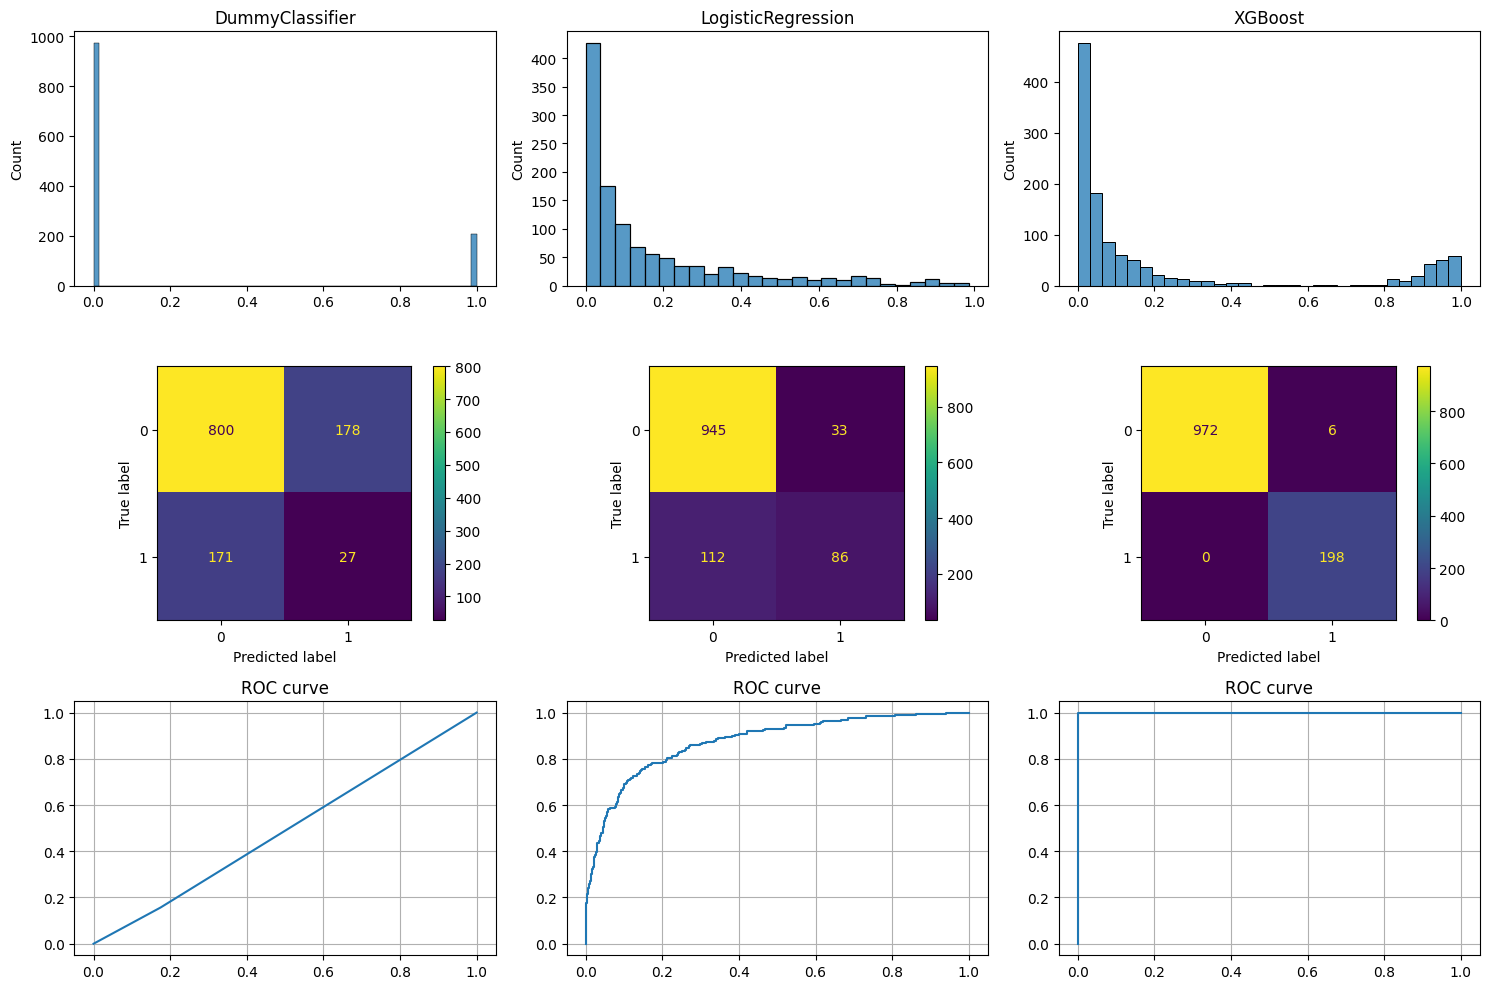

In [92]:
print_results(results_list, train_results_list)
display_results(results_list, train_results_list)

# recherche du meilleur seuil (XGBoost)

In [93]:
best_t, best_f1 = 0, 0

for t in range(1, 9, 1):
    threshold = 0.1 * t
    results_list = []
    results_list.append(entrainement_model("XGBoost", XGBoostParams))

    f1 = results_list[0]["f1"]

    if f1 > best_f1:
        best_f1 = f1
        best_t = threshold

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.30000000000000004
Best F1: 0.40404040404040403


In [94]:
threshold = best_t

results_list = []
results_list.append(entrainement_model("DummyClassifier", DummyClassifierParams))
results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
results_list.append(entrainement_model("XGBoost", XGBoostParams))
pass_list.append(results_list)

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred,X,y,clf
0,DummyClassifier,0.731293,0.129630,0.179487,0.150538,-1.335445,0.497587,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, True, False, Fals...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,DummyClassifier(strategy='stratified')
1,LogisticRegression,0.860544,0.477273,0.538462,0.506024,-0.212066,0.775163,"[0.04998012406583956, 0.003395113087282791, 0....","[False, False, True, False, False, False, True...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,"(StandardScaler(), LogisticRegression())"
2,XGBoost,0.799320,0.333333,0.512821,0.404040,-0.744193,0.778984,"[0.056196146, 0.008982177, 0.5300816, 0.011295...","[False, False, True, False, False, True, False...",nombre_participation_pee nb_formations_...,1041 0 184 0 1222 1 67 0 220 ...,"XGBClassifier(base_score=None, booster=None, c..."


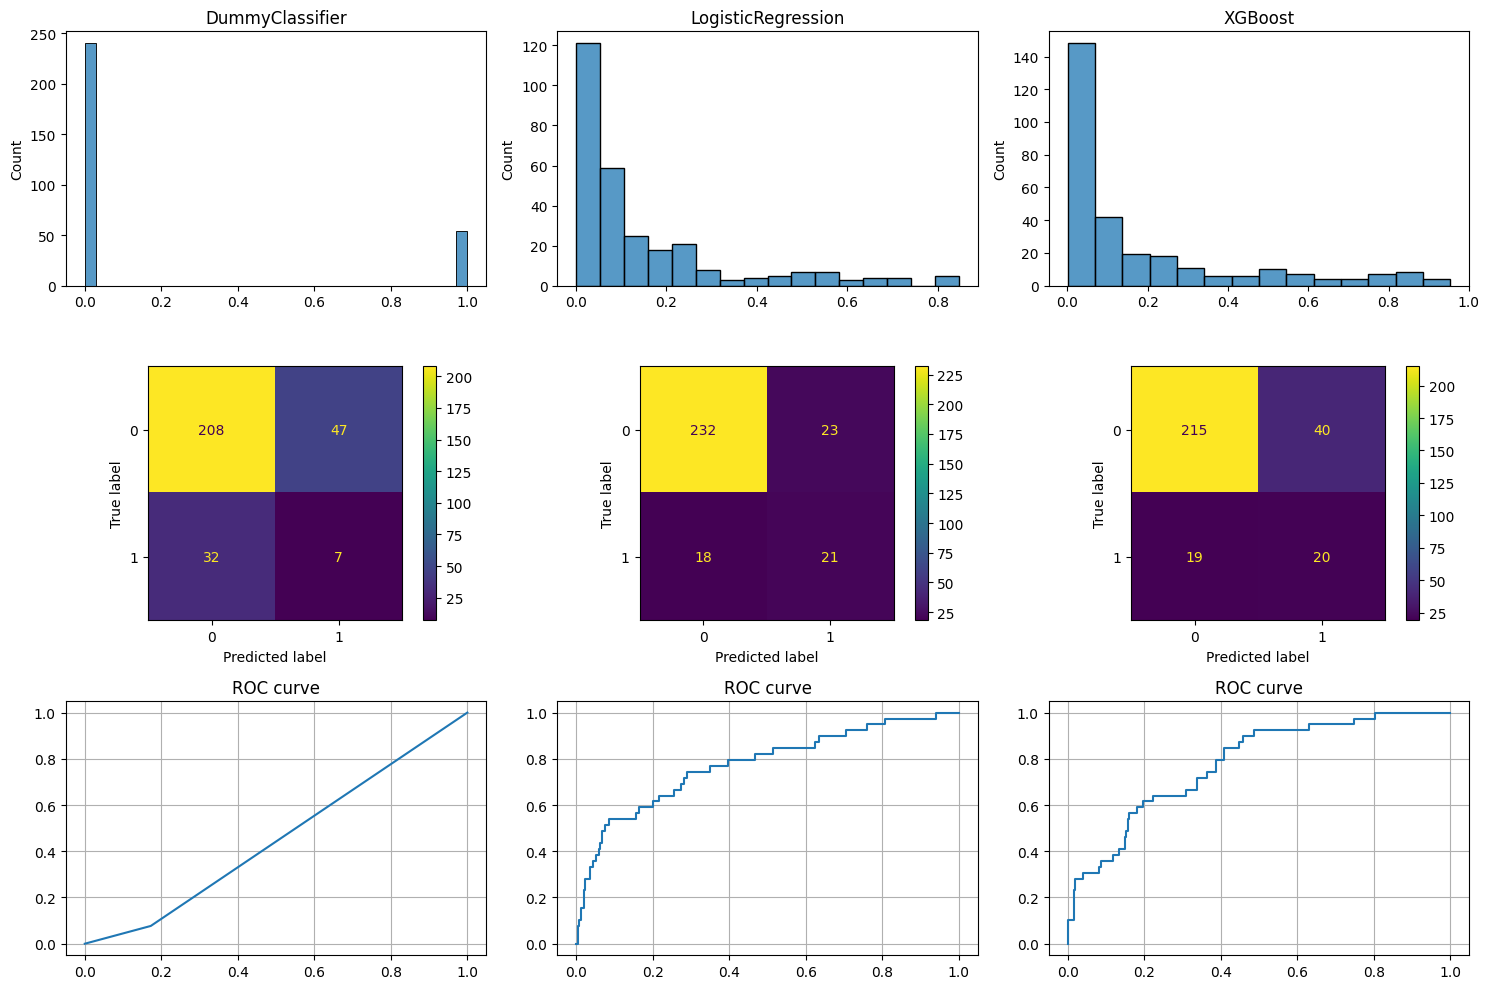

In [95]:
print_results(results_list)
display_results(results_list)

In [96]:
# optimisation des hyperparamètres

# Affiche un graphique de l'évolution du F1-score

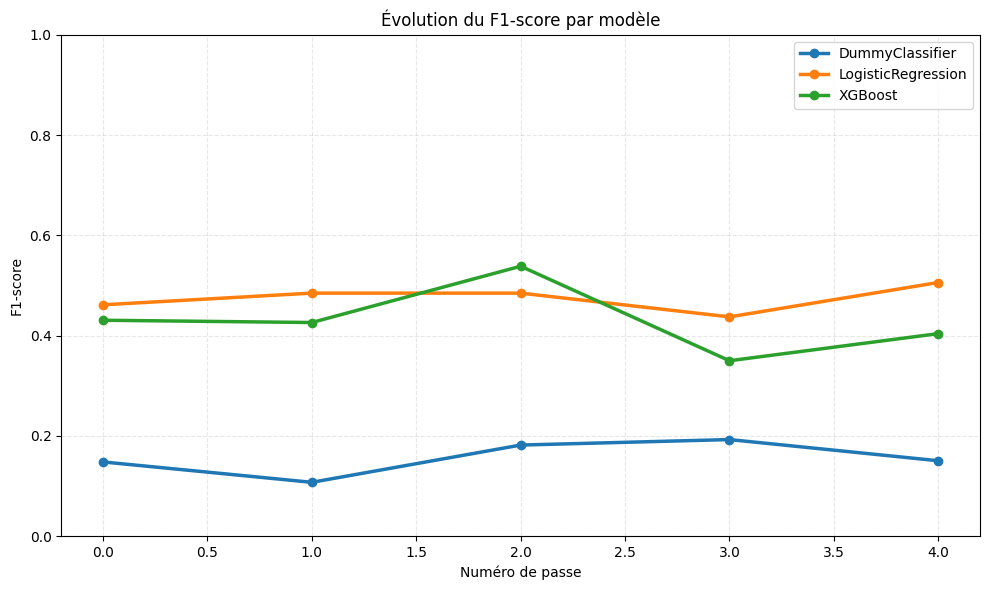

In [97]:
import matplotlib.pyplot as plt
import numpy as np

# noms des modèles (pris sur la première passe)
models = [r["model"] for r in pass_list[0]]

# construction matrice : lignes = passes, colonnes = modèles
data = np.empty((len(pass_list), len(models)))

j = 0
for results_list in pass_list:
    i = 0
    for results in results_list:
        data[j, i] = results["f1"]
        i += 1
    j += 1


# PLOT
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(pass_list))  # numéro de passe

i = 0
for model in models:

    f1_scores = data[:, i]

    ax.plot(
        x,
        f1_scores,
        marker='o',
        linewidth=2.5,
        label=model
    )

    i += 1

ax.set_ylim(0, 1)
ax.set_title("Évolution du F1-score par modèle")
ax.set_xlabel("Numéro de passe")
ax.set_ylabel("F1-score")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [98]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,int64
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,niveau_education,int64
5,annees_depuis_la_derniere_promotion,int64
6,annes_sous_responsable_actuel,int64
7,age,int64
8,revenu_mensuel,int64
9,nombre_experiences_precedentes,int64


# Prédictions sur de nouvelles données

# Export

In [99]:
df.to_parquet("model.parquet")